In [8]:
import tensorflow as tf
import numpy as np

In [9]:
a=tf.constant(5)# imputable
b=tf.constant(3)

c=a+b
print(type(c))
print(c.numpy())

<class 'tensorflow.python.framework.ops.EagerTensor'>
8


In [10]:
d=tf.Variable(8)# mutable
d.assign(9)
print(c.numpy())

8


In [11]:
tensor=tf.constant(([1,2],[3,4]))
print(tensor)

tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)


In [12]:
reshaped=tf.reshape(tensor=tensor,shape=[4,1])
print(reshaped)

tf.Tensor(
[[1]
 [2]
 [3]
 [4]], shape=(4, 1), dtype=int32)


In [13]:
from tensorflow.keras.datasets import mnist

(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow import keras
import pandas as pd

In [15]:
input_shape=x_train[0].shape

In [20]:
model=Sequential([
    layers.Flatten(input_shape=input_shape),
    layers.BatchNormalization(),

    layers.Dense(units=128,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(units=64,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(units=10,activation='softmax')

])

d:\Projects\AI-pipelines\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
 )

In [24]:
early_stopping=keras.callbacks.EarlyStopping(
    patience=5,
    min_delta=0.001,
    restore_best_weights=True
)

history=model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    batch_size=512,
    epochs=100,
    callbacks=[early_stopping],
)

Epoch 1/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7957 - loss: 0.6756 - val_accuracy: 0.9239 - val_loss: 0.2647
Epoch 2/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9145 - loss: 0.2926 - val_accuracy: 0.9445 - val_loss: 0.1873
Epoch 3/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9329 - loss: 0.2267 - val_accuracy: 0.9523 - val_loss: 0.1607
Epoch 4/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9428 - loss: 0.1893 - val_accuracy: 0.9586 - val_loss: 0.1496
Epoch 5/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9519 - loss: 0.1615 - val_accuracy: 0.9617 - val_loss: 0.1426
Epoch 6/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9565 - loss: 0.1439 - val_accuracy: 0.9648 - val_loss: 0.1351
Epoch 7/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9619 - loss: 0.1274 - val_accuracy: 0.9668 - val_loss: 0.1306
Epoch 8/100
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9640 - loss: 0.1166 - 

In [27]:
from matplotlib.pyplot import plot

<Axes: title={'center': 'Accuracy'}>

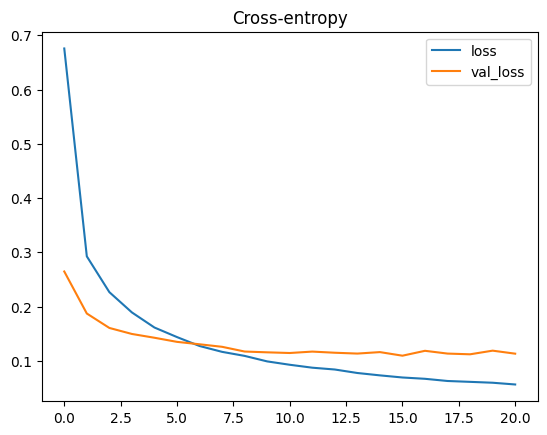

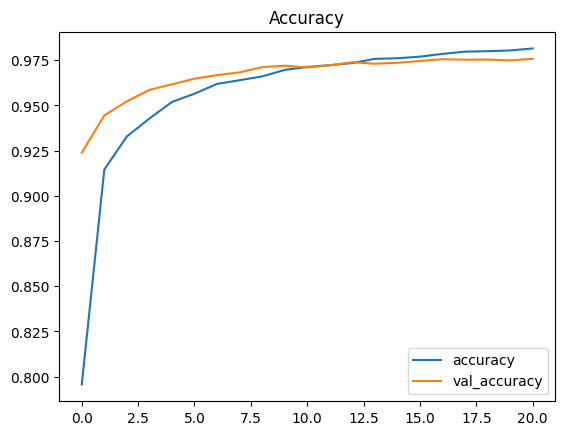

In [28]:
history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Cross-entropy")
history_df.loc[:, ['accuracy', 'val_accuracy']].plot(title="Accuracy")